Tarefa Individual – Modelagem Preditiva com Algoritmos Supervisionados

**Nome completo:** Thaís da Silva Ferreira  
**Base escolhida:** Bank Marketing  
**Tipo de problema:** Classificação supervisionada  
**Objetivo:** prever se um cliente irá aderir ou não a uma campanha de marketing bancário, usando variáveis demográficas, financeiras e informações de contato da campanha.

Definição do Problema

1. O que queremos resolver?
Nosso objetivo é descobrir quais clientes têm mais chance de aceitar a nossa campanha.
Como só existem duas possibilidades de resposta (o cliente aceita ou não aceita), chamamos isso de um problema de duas saídas (ou "classificação binária"). Nossos dados são "desbalanceados", o que significa que temos muito mais respostas de um tipo (geralmente "não") do que do outro. Por causa disso, olhar apenas para a taxa geral de acertos pode ser uma ilusão. Para medir se o modelo é realmente inteligente, precisaremos olhar para avaliações mais detalhadas que mostrem onde ele está errando e acertando.

2. O que será considerado um sucesso?

Acertar muito mais na hora de encontrar os clientes que dizem "sim";
Ter um bom equilíbrio (não dar muitos falsos alarmes, mas também não deixar clientes interessados passarem despercebidos);
Testar e comparar duas técnicas diferentes (Regressão Logística e Naive Bayes) para ver qual delas resolve o problema da melhor forma.


In [1]:
## 2. Preparação do Ambiente

# Importação das bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

In [11]:
# =========================================
# 3. Coleta e Carregamento dos Dados
# A base escolhida foi a **Bank Marketing**, que contém dados de campanhas de marketing direto realizadas por uma instituição bancária. O arquivo principal utilizado é o `bank-full.csv`.
# =========================================

import os
import zipfile
import pandas as pd

# caminho principal do arquivo
caminho_csv = 'bank+marketing/bank/bank-full.csv'

if os.path.exists(caminho_csv):
    df = pd.read_csv(caminho_csv, sep=';')

elif os.path.exists('bank.zip'):
    with zipfile.ZipFile('bank.zip') as z:
        with z.open('bank-full.csv') as f:
            df = pd.read_csv(f, sep=';')

elif os.path.exists('bank+marketing.zip'):
    with zipfile.ZipFile('bank+marketing.zip') as z_principal:
        z_principal.extractall('bank_extraido')

    caminho_extraido = 'bank_extraido/bank-full.csv'

    if os.path.exists(caminho_extraido):
        df = pd.read_csv(caminho_extraido, sep=';')
    else:
        raise FileNotFoundError('bank-full.csv não encontrado dentro do ZIP.')

else:
    raise FileNotFoundError(
        'Arquivo bank-full.csv não encontrado.'
    )

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
# Dimensão da base
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')

Quantidade de linhas: 45211
Quantidade de colunas: 17


In [13]:
# Informações gerais da base
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [14]:
# =========================================
# 4. Verificação da Qualidade dos Dados
# =========================================

# Verificação de valores ausentes tradicionais
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Valores ausentes por coluna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [15]:
# Verificação de registros duplicados
print('Quantidade de linhas duplicadas:', df.duplicated().sum())

Quantidade de linhas duplicadas: 0


In [16]:
# Verificação de valores 'unknown' em variáveis categóricas
colunas_categoricas = df.select_dtypes(include='object').columns

unknowns = {}
for col in colunas_categoricas:
    unknowns[col] = (df[col] == 'unknown').sum()

pd.DataFrame.from_dict(unknowns, orient='index', columns=['quantidade_unknown']).sort_values(
    by='quantidade_unknown', ascending=False
)

,quantidade_unknown
poutcome,36959
contact,13020
education,1857
job,288
marital,0
default,0
loan,0
housing,0
month,0
y,0


A base não possui valores ausentes no formato `NaN`, porém algumas colunas categóricas possuem o valor `unknown`, que representa informação desconhecida. Neste trabalho, esses valores serão mantidos como uma categoria válida, pois podem carregar informação útil para o modelo.

In [17]:
# =========================================
# 5. Análise Exploratória de Dados - EDA
# =========================================

# Estatísticas descritivas das variáveis numéricas
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


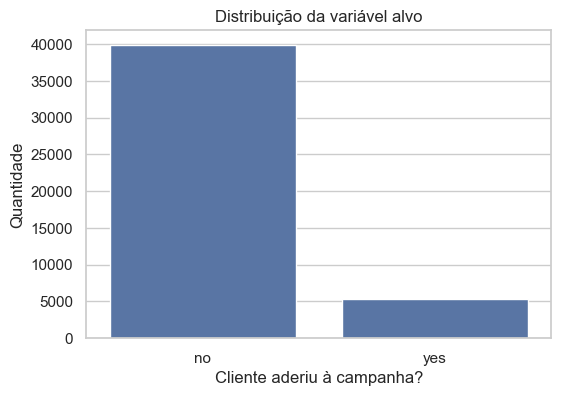

y
no     39922
yes     5289
Name: count, dtype: int64

Percentual:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [19]:
# Distribuição da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')

plt.title('Distribuição da variável alvo')
plt.xlabel('Cliente aderiu à campanha?')
plt.ylabel('Quantidade')

plt.show()

print(df['y'].value_counts())

print()
print('Percentual:')

print(df['y'].value_counts(normalize=True) * 100)

A variável alvo é desbalanceada. A maioria dos clientes não aderiu à campanha. Por esse motivo, é importante avaliar precision, recall, F1-score e ROC AUC, e não apenas a acurácia.

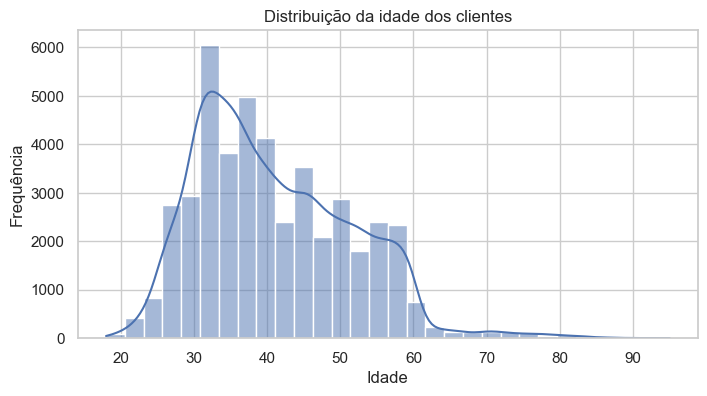

In [20]:
# Distribuição da idade
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='age', bins=30, kde=True)
plt.title('Distribuição da idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

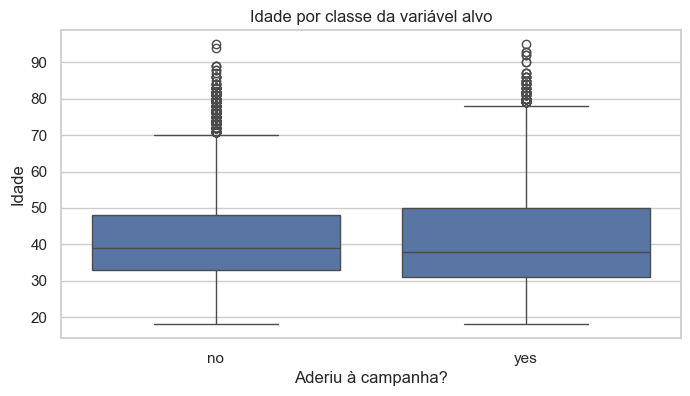

In [21]:
# Relação entre idade e adesão à campanha
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='y', y='age')
plt.title('Idade por classe da variável alvo')
plt.xlabel('Aderiu à campanha?')
plt.ylabel('Idade')
plt.show()

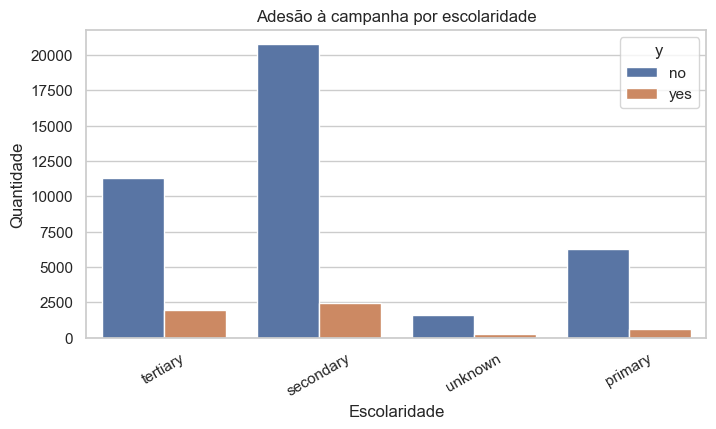

In [22]:
# Adesão por escolaridade
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='education', hue='y')
plt.title('Adesão à campanha por escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade')
plt.xticks(rotation=30)
plt.show()

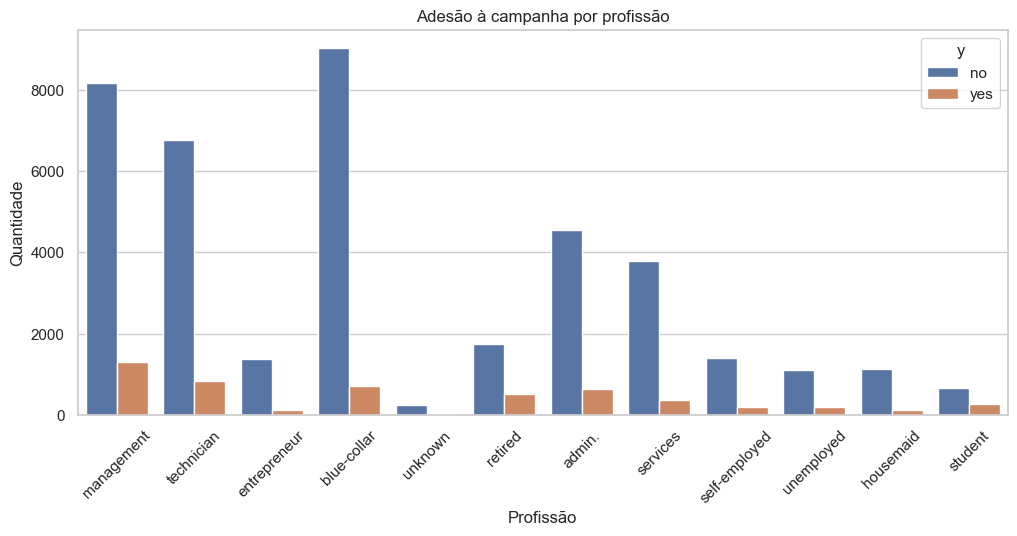

In [23]:
# Adesão por tipo de trabalho
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='job', hue='y')
plt.title('Adesão à campanha por profissão')
plt.xlabel('Profissão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

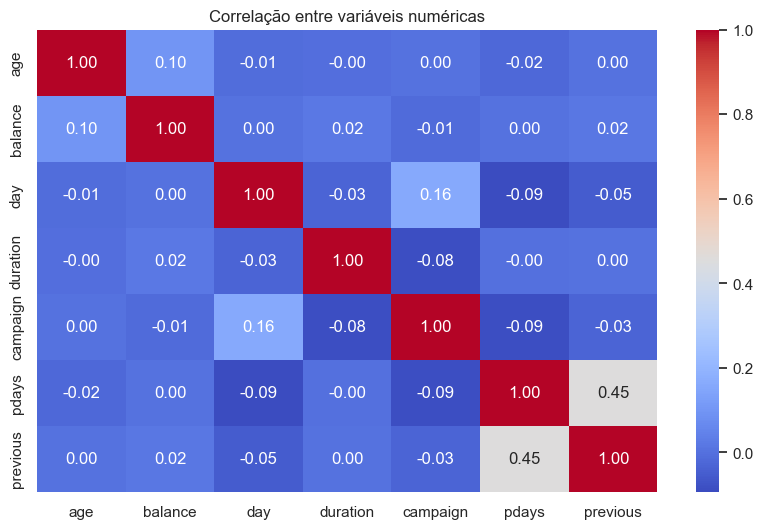

In [24]:
# Mapa de correlação das variáveis numéricas
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.show()

Ao analisar os dados iniciais, percebemos que a decisão do cliente parece ser influenciada por fatores como idade, escolaridade, profissão, histórico em outras campanhas e o tempo que a ligação durou. Um ponto de grande atenção é justamente o tempo de ligação (a variável duration). Ela costuma ser um forte indicador de que o cliente vai aceitar a oferta. O problema é que, na vida real, é impossível saber quanto tempo a conversa vai durar antes mesmo de ligar para a pessoa.

In [25]:
# =========================================
# 6. Pré-processamento dos Dados
# =========================================

# Separação entre variáveis preditoras e variável alvo
X = df.drop('y', axis=1)
y = df['y'].map({'no': 0, 'yes': 1})

# Identificação das colunas numéricas e categóricas
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

print('Colunas numéricas:', colunas_numericas)
print('Colunas categóricas:', colunas_categoricas)

Colunas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Colunas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [27]:
# Divisão em treino e teste
# stratify=y mantém a proporção das classes em treino e teste.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

print()
print('Distribuição da variável alvo no treino:')
print(y_train.value_counts(normalize=True))

print()
print('Distribuição da variável alvo no teste:')
print(y_test.value_counts(normalize=True))

Treino: (31647, 16)
Teste: (13564, 16)

Distribuição da variável alvo no treino:
y
0    0.883022
1    0.116978
Name: proportion, dtype: float64

Distribuição da variável alvo no teste:
y
0    0.882999
1    0.117001
Name: proportion, dtype: float64


In [28]:
# Pipeline de pré-processamento
# Variáveis numéricas: padronização
# Variáveis categóricas: One-Hot Encoding

preprocessamento = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ]
)

## 7. Seleção e Treinamento dos Modelos

Foram escolhidos dois algoritmos supervisionados:

1. **Regressão Logística:** modelo simples, interpretável e adequado para classificação binária.
2. **Naive Bayes Gaussiano:** modelo probabilístico, rápido e útil como comparação de desempenho.


In [29]:
# =========================================
# 7.1 Modelo 1 - Regressão Logística com ajuste de hiperparâmetro
# =========================================

# Pipeline da Regressão Logística
modelo_logistico = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    ('classificador', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Grade de hiperparâmetros
parametros_logistico = {
    'classificador__C': [0.01, 0.1, 1, 10]
}

busca_logistica = GridSearchCV(
    modelo_logistico,
    parametros_logistico,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

busca_logistica.fit(X_train, y_train)

print('Melhores parâmetros:', busca_logistica.best_params_)
print('Melhor F1 médio na validação:', busca_logistica.best_score_)

Melhores parâmetros: {'classificador__C': 10}
Melhor F1 médio na validação: 0.552934810608243


In [30]:
# =========================================
# 7.2 Modelo 2 - Naive Bayes com ajuste de hiperparâmetro
# =========================================

# Para usar GaussianNB, o resultado do OneHotEncoder precisa ser denso.
# sparse_output=False funciona em versões mais novas do scikit-learn.
# Caso sua versão seja antiga, troque por sparse=False.

try:
    encoder_nb = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder_nb = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessamento_nb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', encoder_nb, colunas_categoricas)
    ]
)

modelo_nb = Pipeline(steps=[
    ('preprocessamento', preprocessamento_nb),
    ('classificador', GaussianNB())
])

parametros_nb = {
    'classificador__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

busca_nb = GridSearchCV(
    modelo_nb,
    parametros_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

busca_nb.fit(X_train, y_train)

print('Melhores parâmetros:', busca_nb.best_params_)
print('Melhor F1 médio na validação:', busca_nb.best_score_)

Melhores parâmetros: {'classificador__var_smoothing': 1e-09}
Melhor F1 médio na validação: 0.4458193585295788


In [31]:
# =========================================
# 8. Avaliação dos Modelos
# =========================================

# Função para avaliar modelos

def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    metricas = {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }
    
    print(f'===== {nome} =====')
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
    
    matriz = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()
    
    return metricas, y_pred, y_prob

===== Regressão Logística =====
              precision    recall  f1-score   support

          no       0.97      0.85      0.91     11977
         yes       0.42      0.81      0.55      1587

    accuracy                           0.85     13564
   macro avg       0.69      0.83      0.73     13564
weighted avg       0.91      0.85      0.87     13564



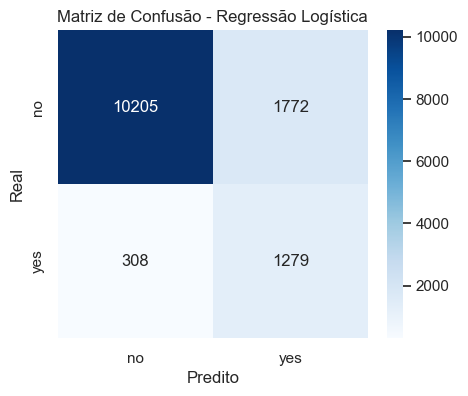

===== Naive Bayes =====
              precision    recall  f1-score   support

          no       0.93      0.90      0.91     11977
         yes       0.40      0.51      0.45      1587

    accuracy                           0.85     13564
   macro avg       0.67      0.70      0.68     13564
weighted avg       0.87      0.85      0.86     13564



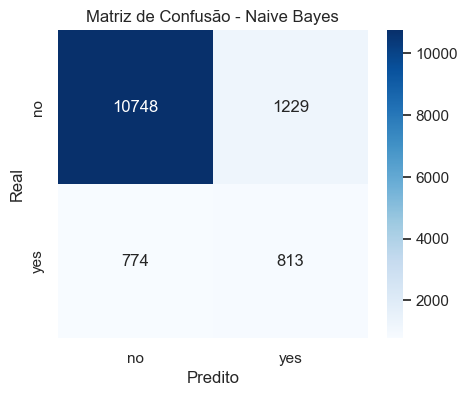

In [32]:
metricas_log, y_pred_log, y_prob_log = avaliar_modelo(
    'Regressão Logística',
    busca_logistica.best_estimator_,
    X_test,
    y_test
)

metricas_nb, y_pred_nb, y_prob_nb = avaliar_modelo(
    'Naive Bayes',
    busca_nb.best_estimator_,
    X_test,
    y_test
)

In [33]:
# Comparação das métricas
resultado_metricas = pd.DataFrame([metricas_log, metricas_nb])
resultado_metricas

,Modelo,Acurácia,Precisão,Recall,F1-score,ROC AUC
0,Regressão Logística,0.846653,0.419207,0.805923,0.551531,0.907443
1,Naive Bayes,0.852330,0.398139,0.512287,0.448057,0.806682


<Figure size 1000x500 with 0 Axes>

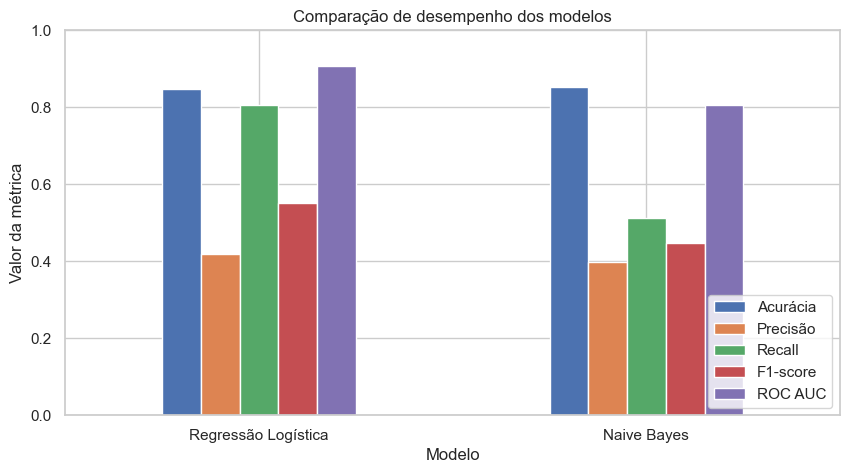

In [34]:
# Gráfico comparativo das métricas
resultado_plot = resultado_metricas.set_index('Modelo')

plt.figure(figsize=(10,5))
resultado_plot.plot(kind='bar', figsize=(10,5))
plt.title('Comparação de desempenho dos modelos')
plt.ylabel('Valor da métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

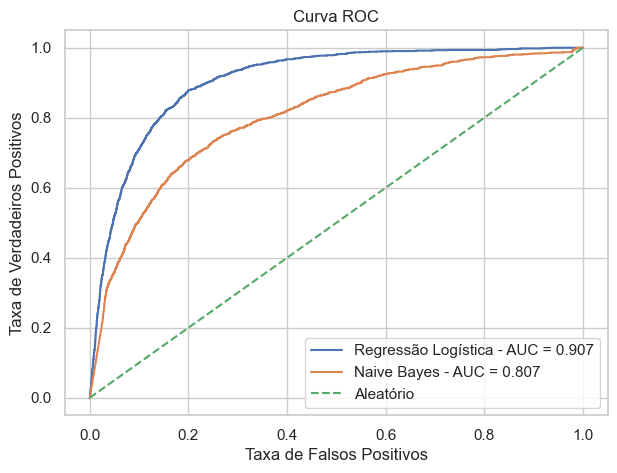

In [35]:
# Curva ROC dos modelos
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Regressão Logística - AUC = {metricas_log["ROC AUC"]:.3f}')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes - AUC = {metricas_nb["ROC AUC"]:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Aleatório')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend()
plt.show()

In [36]:
# =========================================
# 9. Análise de Erros
# =========================================

# Análise dos erros do melhor modelo pelo F1-score
melhor_nome = resultado_metricas.sort_values(by='F1-score', ascending=False).iloc[0]['Modelo']

if melhor_nome == 'Regressão Logística':
    melhor_modelo = busca_logistica.best_estimator_
    melhor_pred = y_pred_log
    melhor_prob = y_prob_log
else:
    melhor_modelo = busca_nb.best_estimator_
    melhor_pred = y_pred_nb
    melhor_prob = y_prob_nb

print('Melhor modelo pelo F1-score:', melhor_nome)

erros = X_test.copy()
erros['y_real'] = y_test.values
erros['y_predito'] = melhor_pred
erros['probabilidade_yes'] = melhor_prob

erros_modelo = erros[erros['y_real'] != erros['y_predito']]
erros_modelo.head(10)

Melhor modelo pelo F1-score: Regressão Logística


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y_real,y_predito,probabilidade_yes
44332,35,unemployed,single,tertiary,no,154,no,no,cellular,29,jul,200,4,181,2,failure,1,0,0.352264
38581,44,services,single,secondary,no,532,yes,no,cellular,15,may,550,2,340,2,failure,0,1,0.699342
43340,37,technician,married,secondary,no,1458,no,no,cellular,22,mar,344,1,326,1,success,0,1,0.994869
30229,27,admin.,single,secondary,no,592,yes,yes,cellular,5,feb,466,3,-1,0,unknown,0,1,0.624165
25782,59,retired,married,secondary,no,32948,no,no,cellular,19,nov,243,1,174,2,failure,0,1,0.681157
41685,39,admin.,married,secondary,no,26233,no,no,cellular,2,oct,462,1,-1,0,unknown,0,1,0.972232
19358,41,management,divorced,secondary,no,0,no,no,cellular,6,aug,438,2,-1,0,unknown,0,1,0.615982
32857,26,self-employed,single,tertiary,no,3044,yes,yes,cellular,17,apr,550,1,325,1,other,0,1,0.824476
32529,28,student,single,secondary,no,378,yes,no,cellular,17,apr,346,1,-1,0,unknown,0,1,0.769829
32467,48,management,married,secondary,no,117,yes,no,cellular,16,apr,635,1,-1,0,unknown,0,1,0.857094


In [38]:
# Quantidade de tipos de erro
falsos_positivos = erros[(erros['y_real'] == 0) & (erros['y_predito'] == 1)]
falsos_negativos = erros[(erros['y_real'] == 1) & (erros['y_predito'] == 0)]

print('Falsos positivos:', falsos_positivos.shape[0])
print('Falsos negativos:', falsos_negativos.shape[0])

Falsos positivos: 1772
Falsos negativos: 308


A análise de erros permite observar onde o modelo mais falha. Falsos positivos são clientes previstos como aderentes, mas que não aceitaram a campanha. Falsos negativos são clientes que aceitariam a campanha, mas foram classificados como não aderentes. Para campanhas de marketing, reduzir falsos negativos pode ser importante quando o objetivo é não perder potenciais clientes.

10. Interpretação dos Resultados

A Regressão Logística tende a ser uma boa escolha quando se busca interpretabilidade e equilíbrio entre as métricas. O uso de `class_weight='balanced'` ajuda a lidar com o desbalanceamento da variável alvo, dando maior peso à classe minoritária.

O Naive Bayes é um modelo simples e rápido, servindo como uma boa linha de comparação. Porém, ele assume independência entre as variáveis, o que pode limitar seu desempenho em bases com muitas relações entre atributos.

A escolha final deve considerar principalmente o **F1-score**, o **recall da classe yes** e o **ROC AUC**, pois a classe de maior interesse é a dos clientes que aderem à campanha.

11. Conclusão

Neste projeto foi desenvolvido um processo completo de modelagem preditiva supervisionada utilizando a base Bank Marketing. O problema foi tratado como classificação binária, com o objetivo de prever a adesão de clientes a uma campanha bancária.

Foram realizadas as etapas de carregamento dos dados, verificação de qualidade, análise exploratória, pré-processamento, divisão em treino e teste, treinamento de dois modelos, ajuste de hiperparâmetros e avaliação por métricas adequadas.

Como a base é desbalanceada, a avaliação considerou métricas como precision, recall, F1-score e ROC AUC. O melhor modelo deve ser escolhido com base no equilíbrio entre essas métricas, principalmente considerando a capacidade de identificar corretamente clientes da classe `yes`.
